In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import ast
import math

PATH_ACTIONS    = "../Data/Processed/actions_filtered.csv"
PATH_KEYPOINTS  = "../Data/tmp/keypoints.csv"
PATH_TEST       = "../Data/tmp/test_out.csv"
PATH_CLIPS      = "../Data/Videos/Clips/"

TEST_CLIP       = "1/11_Left.mp4"
#TEST_CLIP       = "5/1_Left.mp4"

In [22]:
df_actions = pd.read_csv(PATH_ACTIONS)
true_actions = df_actions[df_actions["file"] == TEST_CLIP]

print(true_actions)

            file fencer  action_id                 action  start_frame  \
2  1/11_Left.mp4   LEFT          2           ATTACK_LUNGE           60   
3  1/11_Left.mp4  RIGHT          3  DEFENSE_DISTANCE_PULL           22   
4  1/11_Left.mp4  RIGHT          4           ATTACK_BASIC           56   

   end_frame  
2         65  
3         40  
4         61  


In [23]:
df_test = pd.read_csv(PATH_TEST)

left_df = pd.DataFrame({
    "frame": df_test["frame_idx"],
    "fencer": "LEFT",
    "pred_label": df_test["left_label"],
    "keypoints": df_test["left_keypoints"],
})

right_df = pd.DataFrame({
    "frame": df_test["frame_idx"],
    "fencer": "RIGHT",
    "pred_label": df_test["right_label"],
    "keypoints": df_test["right_keypoints"],
})

df_test = pd.concat([left_df, right_df], ignore_index=True)
df_test.sort_values(["frame", "fencer"]).reset_index(drop=True)

print(df_test)

     frame fencer             pred_label  \
0        0   LEFT              NO_ACTION   
1        1   LEFT              NO_ACTION   
2        2   LEFT              NO_ACTION   
3        3   LEFT           ATTACK_BASIC   
4        4   LEFT  DEFENSE_DISTANCE_PULL   
..     ...    ...                    ...   
127     61  RIGHT           ATTACK_BASIC   
128     62  RIGHT           ATTACK_BASIC   
129     63  RIGHT           ATTACK_LUNGE   
130     64  RIGHT           ATTACK_LUNGE   
131     65  RIGHT           ATTACK_LUNGE   

                                             keypoints  
0    [[586.6571655273438, 616.03759765625], [588.33...  
1    [[591.2735595703125, 613.8451538085938], [592....  
2    [[591.94775390625, 615.4619140625], [593.63360...  
3    [[1220.6787109375, 605.7059326171875], [1226.1...  
4    [[602.3779296875, 619.6385498046875], [604.082...  
..                                                 ...  
127  [[1548.176513671875, 602.2390747070312], [1551...  
128  [[1565.570

In [24]:
merged = df_test.merge(
    true_actions[["fencer", "action", "start_frame", "end_frame"]],
    on="fencer",
    how="left"
)

valid = merged[
    (merged["frame"] >= merged["start_frame"]) &
    (merged["frame"] <= merged["end_frame"])
]

df_filtered = (
    valid[["fencer", "frame", "action", "pred_label", "keypoints"]]
    .drop_duplicates()
    .sort_values(["fencer", "frame"])
    .reset_index(drop=True)
)

df_filtered["keypoints"] = df_filtered["keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

print(df_filtered[["fencer", "frame", "action", "pred_label"]])

   fencer  frame                 action             pred_label
0    LEFT     60           ATTACK_LUNGE  DEFENSE_DISTANCE_PULL
1    LEFT     61           ATTACK_LUNGE  DEFENSE_DISTANCE_PULL
2    LEFT     62           ATTACK_LUNGE  DEFENSE_DISTANCE_PULL
3    LEFT     63           ATTACK_LUNGE           ATTACK_LUNGE
4    LEFT     64           ATTACK_LUNGE           ATTACK_LUNGE
5    LEFT     65           ATTACK_LUNGE           ATTACK_LUNGE
6   RIGHT     22  DEFENSE_DISTANCE_PULL           ATTACK_BASIC
7   RIGHT     23  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
8   RIGHT     24  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
9   RIGHT     25  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
10  RIGHT     26  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
11  RIGHT     27  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
12  RIGHT     28  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
13  RIGHT     29  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
14  RIGHT     30  DEFENSE_DISTANCE_PULL  DEFENSE_DISTAN

In [5]:
EDGES = [
    (0, 1), (1, 3),
    (3, 5), (1, 2),
    (0, 2), (2, 4),
    (4, 6),
    (5, 7), (7, 9),     # left arm
    (6, 8), (8, 10),    # right arm
    (5, 6),             # shoulders
    (11, 12),           # hips
    (5, 11), (6, 12),   # torso
    (11, 13), (13, 15), # left leg
    (12, 14), (14, 16)  # right leg
]

def plot_skeleton(frame, keypoints, color=(0,1,0), alpha=0.8):
    for (i,j) in EDGES:
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        plt.plot([x1, x2], [y1, y2], color=color, alpha=alpha, linewidth=2)
    keypoints = np.array(keypoints)
    plt.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)

def draw_random_frame(df):
    # Pick a random row from the dataframe
    row = df.sample(1).iloc[0]
    video_path = PATH_CLIPS + TEST_CLIP
    frame_idx = row["frame"]
    keypoints = row["keypoints"]

    # Open video
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        print(f"Failed to read frame {frame_idx}")
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,6))
    plt.imshow(frame_rgb)
    plt.axis("off")

    # Draw skeleton
    if keypoints and not (isinstance(keypoints, float) and np.isnan(keypoints)):
        plot_skeleton(frame_rgb, keypoints, color=(0,1,0))

    plt.title(f"Frame {frame_idx}, Fencer: {row['fencer']}, Action: {row['action']}, Prediction: {row['pred_label']}")
    plt.show()

    cap.release()

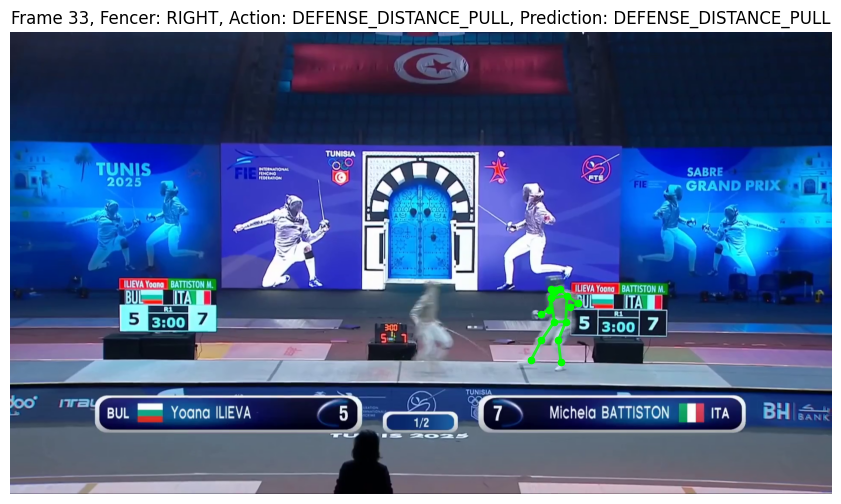

In [35]:
draw_random_frame(df_filtered)

In [11]:
df_keypoints = pd.read_csv(PATH_KEYPOINTS)

df_keypoints["keypoints"] = df_keypoints["keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

df_keypoints["box"] = df_keypoints["box"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_merged = df_keypoints.merge(df_filtered, on=["fencer", "frame"], how="left")

print(df_keypoints)

               file fencer  frame                     box  confidence  \
0     1/10_Left.mp4   LEFT     23    (768, 609, 867, 768)    0.793696   
1     1/10_Left.mp4   LEFT     24    (758, 614, 903, 773)    0.795385   
2     1/10_Left.mp4   LEFT     25    (760, 618, 931, 776)    0.811996   
3     1/10_Left.mp4   LEFT     26    (770, 625, 940, 776)    0.808932   
4     1/10_Left.mp4  RIGHT     21  (1093, 599, 1205, 769)    0.833261   
...             ...    ...    ...                     ...         ...   
4218   6/9_Left.mp4  RIGHT     40  (1024, 574, 1178, 752)    0.883191   
4219   6/9_Left.mp4  RIGHT     41  (1003, 580, 1180, 751)    0.855411   
4220   6/9_Left.mp4  RIGHT     42  (1006, 585, 1189, 749)    0.850276   
4221   6/9_Left.mp4  RIGHT     43  (1013, 582, 1194, 751)    0.815930   
4222   6/9_Left.mp4  RIGHT     44  (1025, 588, 1197, 750)    0.756268   

                                              keypoints  
0     [(823.204345703125, 613.4403076171875), (826.9...  
1     [

In [23]:
ROI = (0, 600, 1900, 850)

def draw_file(df, video_file, cols=2):
    """
    Plot all frames in the DataFrame corresponding to a video file
    in a grid of subplots (cols per row).
    
    df: DataFrame with columns ['frame','fencer','keypoints','action'] and optional 'confidence'
    video_file: filename of the video
    cols: number of columns per row
    """
    video_frames = df[df['file'] == video_file]
    frame_indices = sorted(video_frames['frame'].unique())
    n_frames = len(frame_indices)
    rows = math.ceil(n_frames / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows))
    axes = axes.flatten()  # flatten to 1D array for easy indexing

    video_path = PATH_CLIPS + video_file

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Cannot open video {video_file}")
        return

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        ax = axes[i]
        ax.imshow(frame_rgb)
        ax.axis('off')

        # Draw ROI
        x1r, y1r, x2r, y2r = ROI
        rect = plt.Rectangle((x1r, y1r), x2r-x1r, y2r-y1r,
                             linewidth=2, edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)

        # Draw poses for LEFT and RIGHT fencers
        for fencer in ['LEFT','RIGHT']:
            row = video_frames[(video_frames['frame'] == frame_idx) & (video_frames['fencer'] == fencer)]
            if row.empty:
                continue
            keypoints = row['keypoints'].values[0]
            if keypoints and not (isinstance(keypoints, float) and np.isnan(keypoints)):
                plot_skeleton_ax(ax, keypoints, color=(1,0,0) if fencer=='LEFT' else (0,1,0))

            box = row['box'].values[0]
            if box:
                x1, y1, x2, y2 = box
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
            
            # Display fencer action if available
            ax.set_title(f"{frame_idx}", fontsize=8)

    # Hide any unused subplots
    for j in range(n_frames, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    cap.release()

def plot_skeleton_ax(ax, keypoints, color=(0,1,0), alpha=0.8):
    """Draw skeleton on a given matplotlib axis"""
    keypoints = np.array(keypoints)
    for (i,j) in EDGES:  # assume EDGES is defined globally
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        ax.plot([x1,x2],[y1,y2], color=color, alpha=alpha, linewidth=2)
    ax.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)


             file fencer  action_id        action  start_frame  end_frame
350  5/1_Left.mp4   LEFT        350  ATTACK_LUNGE           23         31
351  5/1_Left.mp4  RIGHT        351  ATTACK_LUNGE           21         31


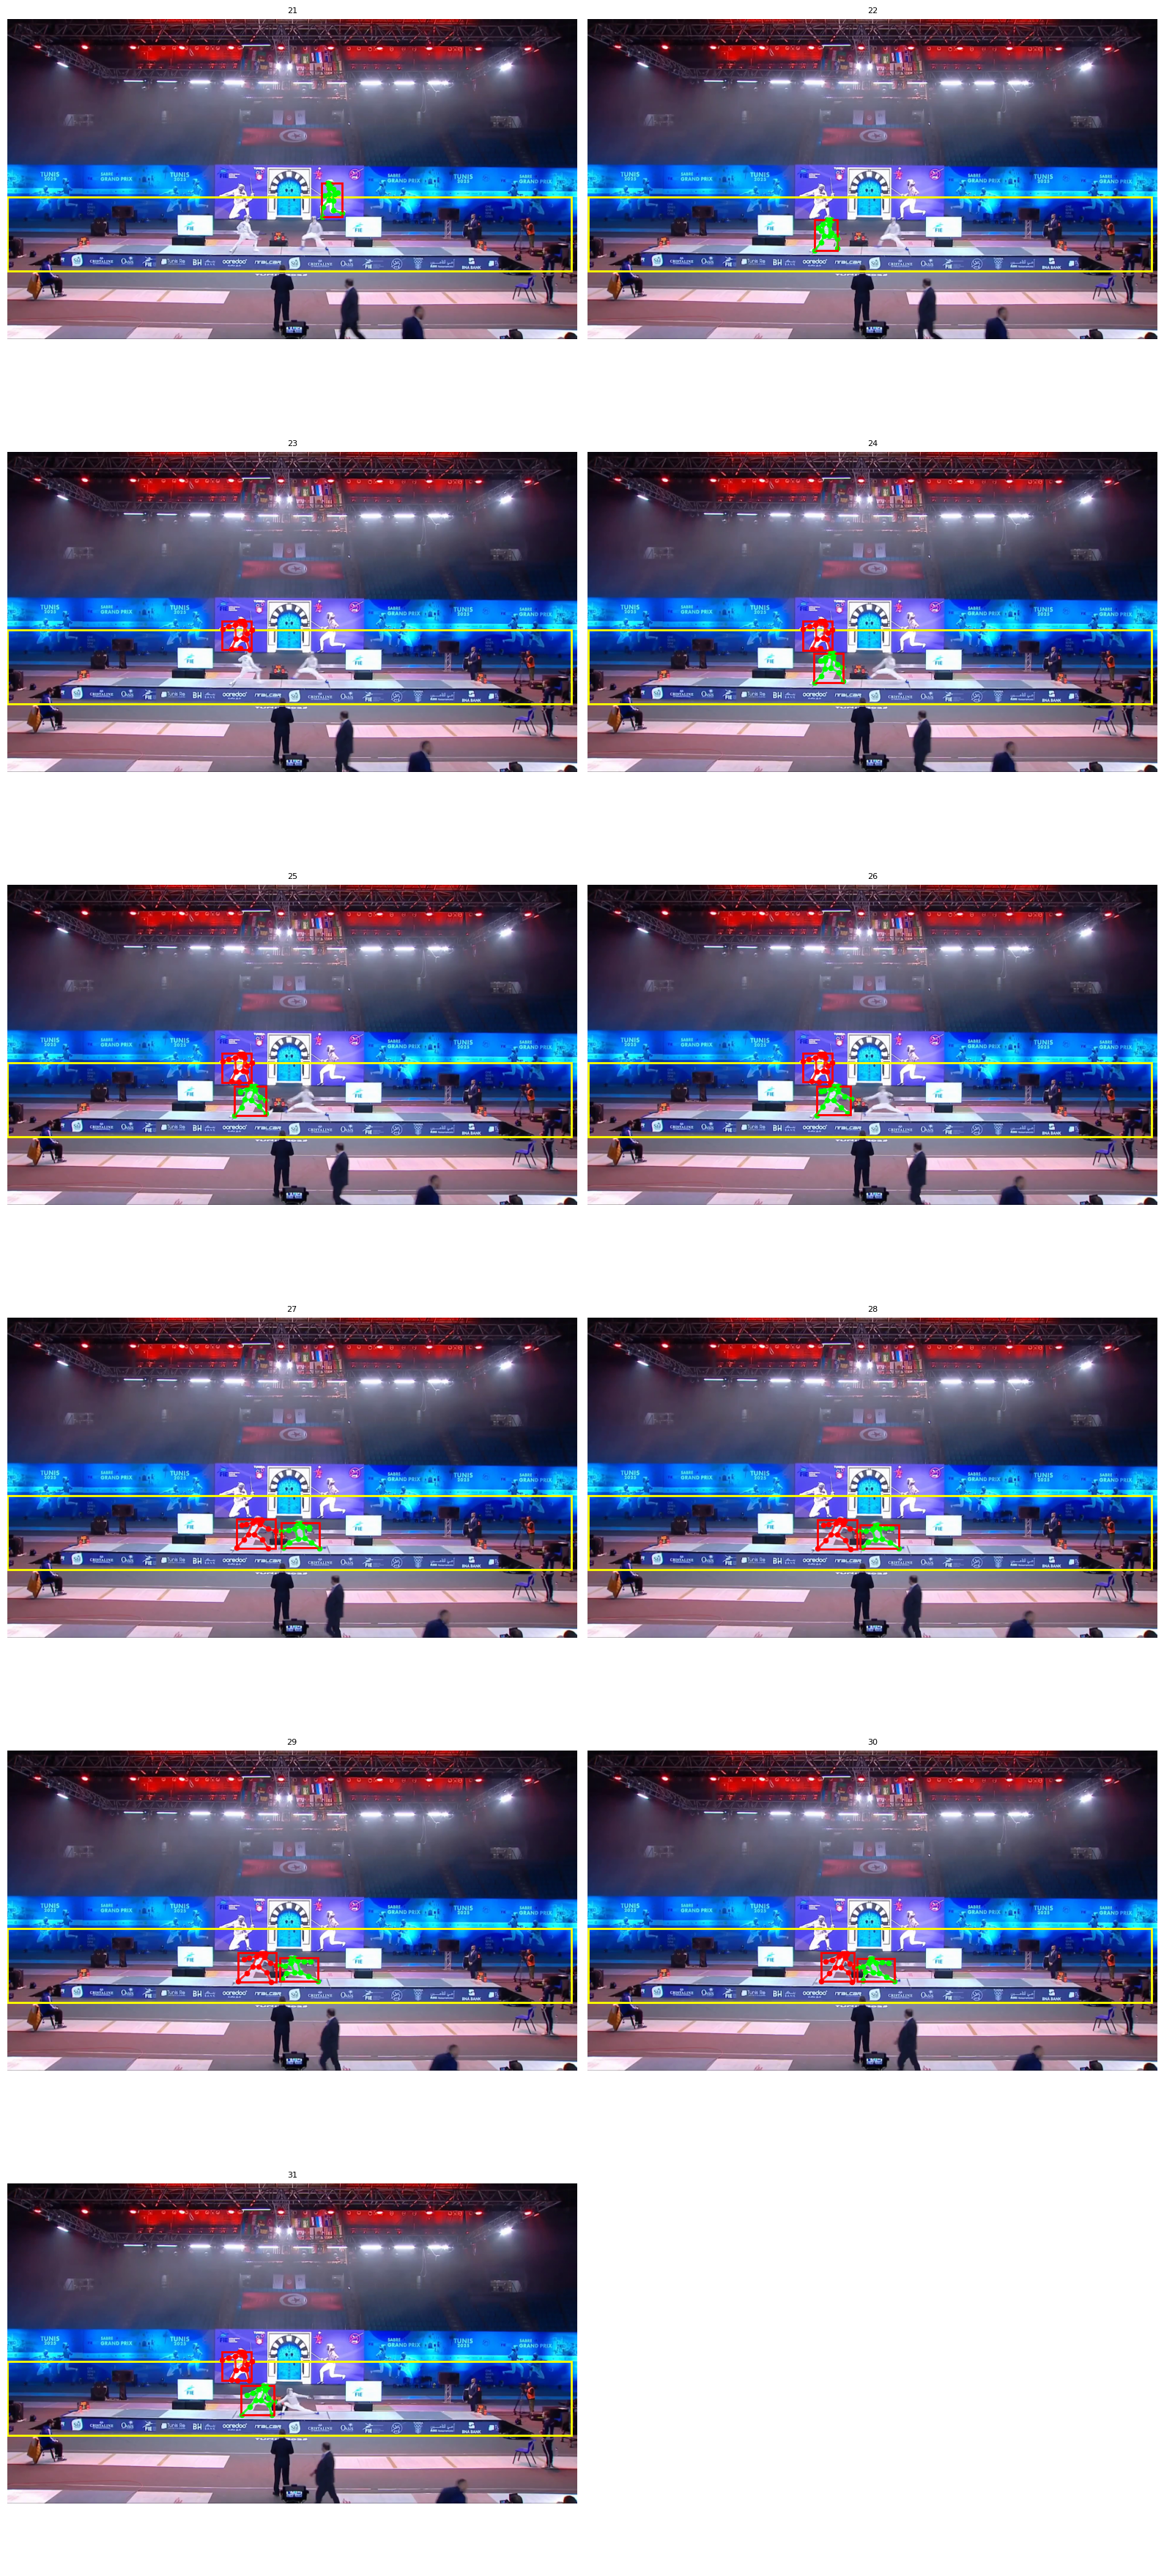

In [24]:
file = "5/1_Left.mp4"

true_actions = df_actions[df_actions["file"] == file]
print(true_actions)

draw_file(df_keypoints, file)